# Support Vector Machines

## The problem

Suppose you have some penguin data with two features:

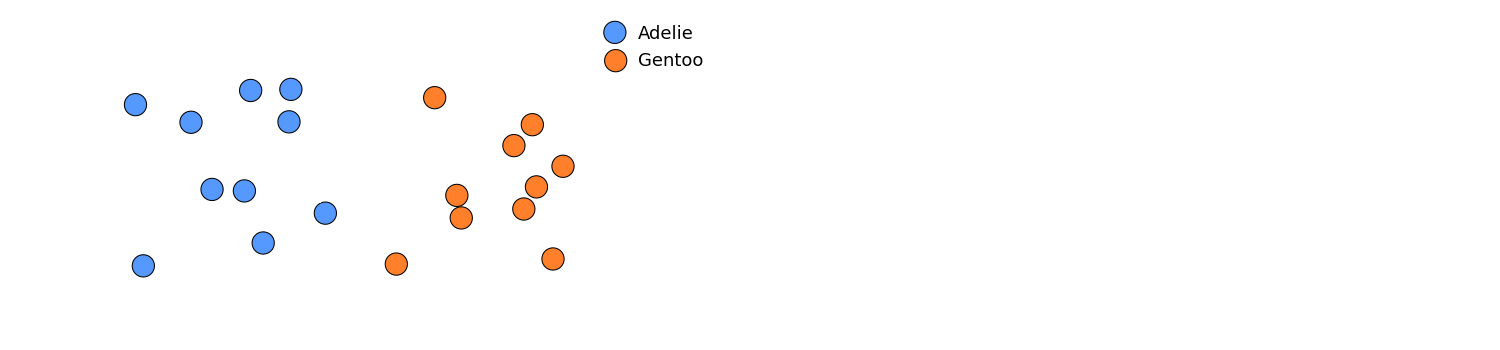

#### **Q:** Which line could separate the classes?

**A:** The two classes are clearly linearly separable, but how do we decide what a "good" linear separation would be?

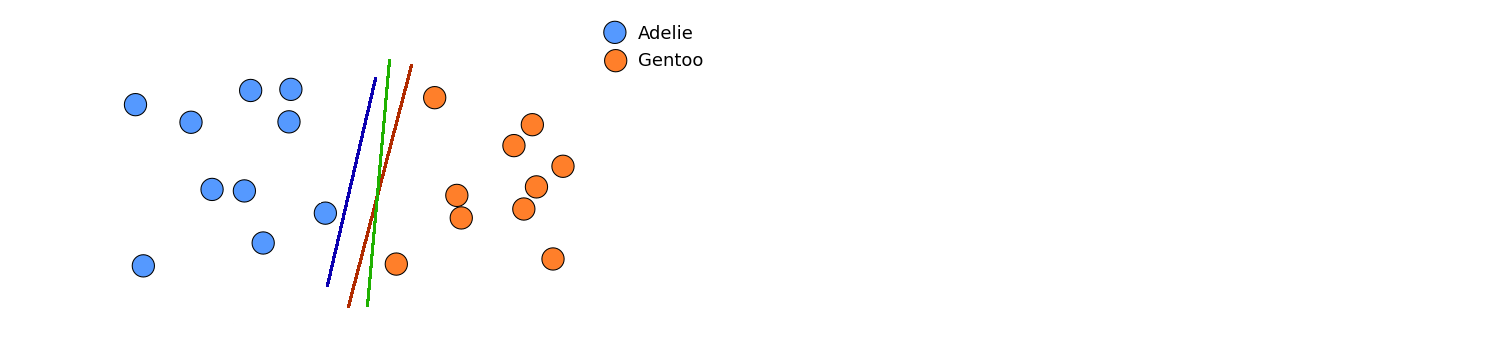

### Solution: The Maximal Margin Classifier

The goal of a Support Vector Classifier is to find a decision boundary that **maximises the separation of the two classes** and to **minimise misclassification**.

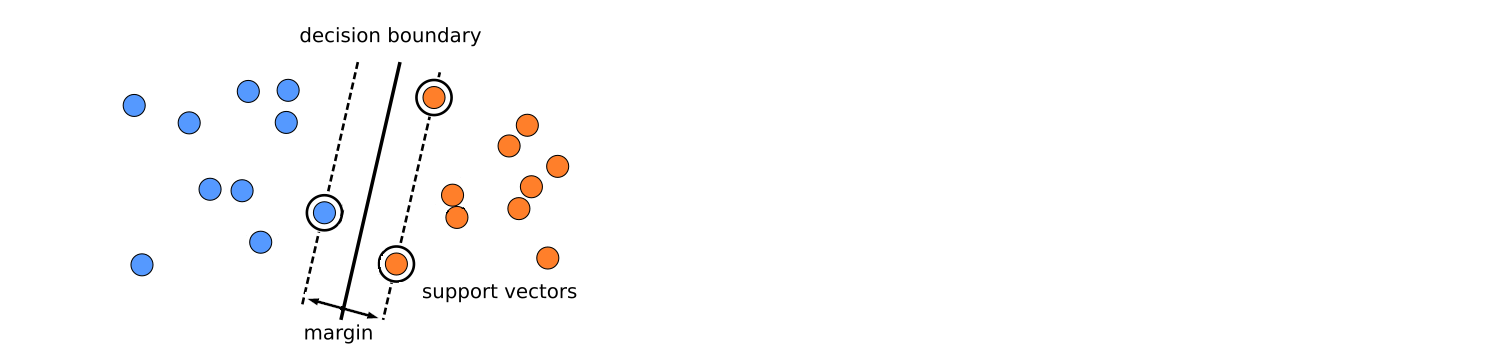

The **loss** function is minimized so that there is a **maximum margin** (the widest "street".)  
As these few (here: 3) data points support the "street" or form the dicision boundary, they are called **support vectors**.

SVM usually use the **hinge loss** to calculate the total loss:
$$L = \sum_{i=1}^{n} max(0, 1 - y_i \cdot f(x_i))$$

with 
$n$: number of data points  
$x_i$: feature values (e.g. $x_1, x_2$) for the `i-th` data point  
$y_i$: true label of the `i-th` data point $y_i \in \{-1, 1\}$  
$f(x_i)$: predicted value for the `i-th` data point, e.g. $f(x) = w_1*x^{1*} + w_2*x^{2*} + b = \left\{
    \begin{array}{ll}
      \ge0, & \mbox{if $y_i=+1$}.\\
      <0, & \mbox{if $y_i=-1$}.
    \end{array}
  \right.$  


That means, $y_i \cdot f(x_i) > 0$ for a correct classification.

## Another problem: Outliers and overlapping

Real world data generally  
- contain outliers
- do not show clear boundaries but overlapping of different classes.

Thus the maximal margin classifier would struggle and lead to an unsatisfactory classification.

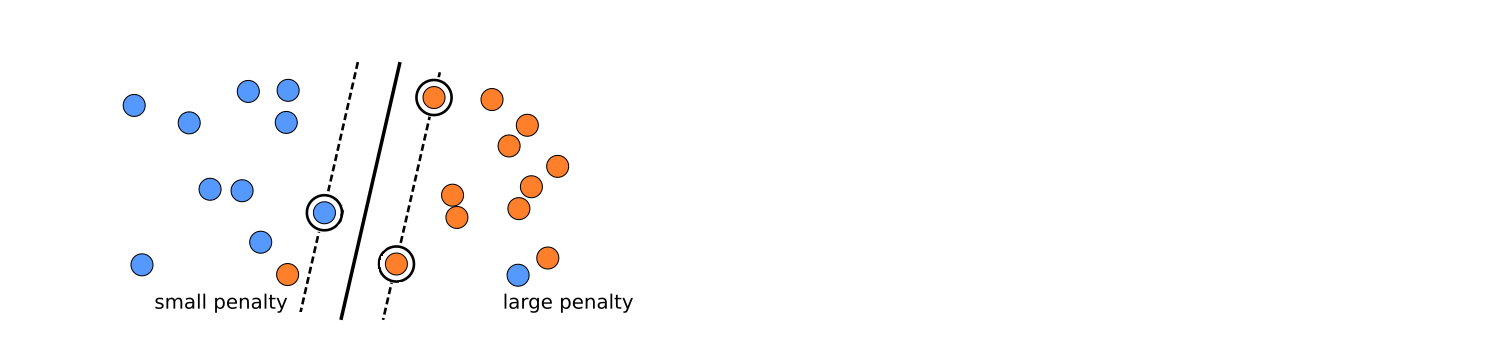

### Solution: Support vector machines

To account for this, two types of concessions are made:
- allow for misclassification (blue dots in red area an vice versa)
- allow observations within the margin, a so-called **soft margin**

Soft margin classifiers are called **Support Vector Machines**, SVM or **Support Vector Classifiers**, SVC

*Sidenote:* This concept also works for regression &rarr; next week. (It's called Support Vector Regression.)

## Yet another problem: Linearly non-separable classes

Consinder the following dataset:

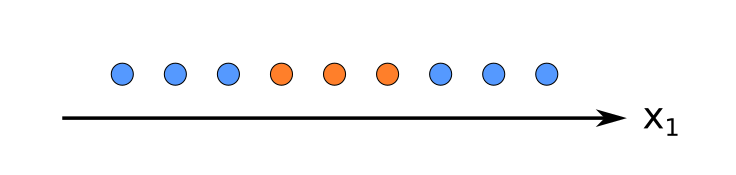

It is one-dimensional (only one feature $x_1$), and two classes: orange and blue. We cannot draw a line through the data in the same way that we did before to give us a good separation of the data with a clear margin.

### Solution: Increase the dimensionality with a kernel function

Analogy in normal life: Consider your problem from within a higher perspective.  
Consider that our 1-dimensional data set is just a projection into 1d space:
If we add a second feature, $x_2 = (x_{1}-x_m)^{2}$, we can easily find a linear boundary in the 2-dimensional space.

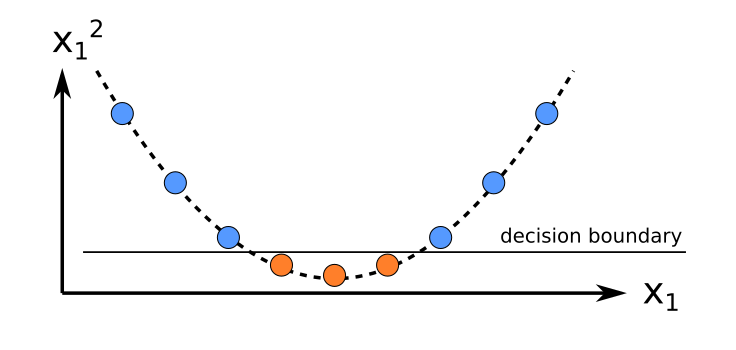

So by putting our data into higher dimensional space, we are able to find a linear decision boundary in that higher-dimensional space that does not look linear in the original data!  
The above example uses a polynome as kernel. "Kernel" is just another word for describing how points are transformed in space. There are also other types of kernels like linear, radial base function (RBF), tanh, sigmoid, ...

We can also do it for 2D data by adding a 3rd dimension:

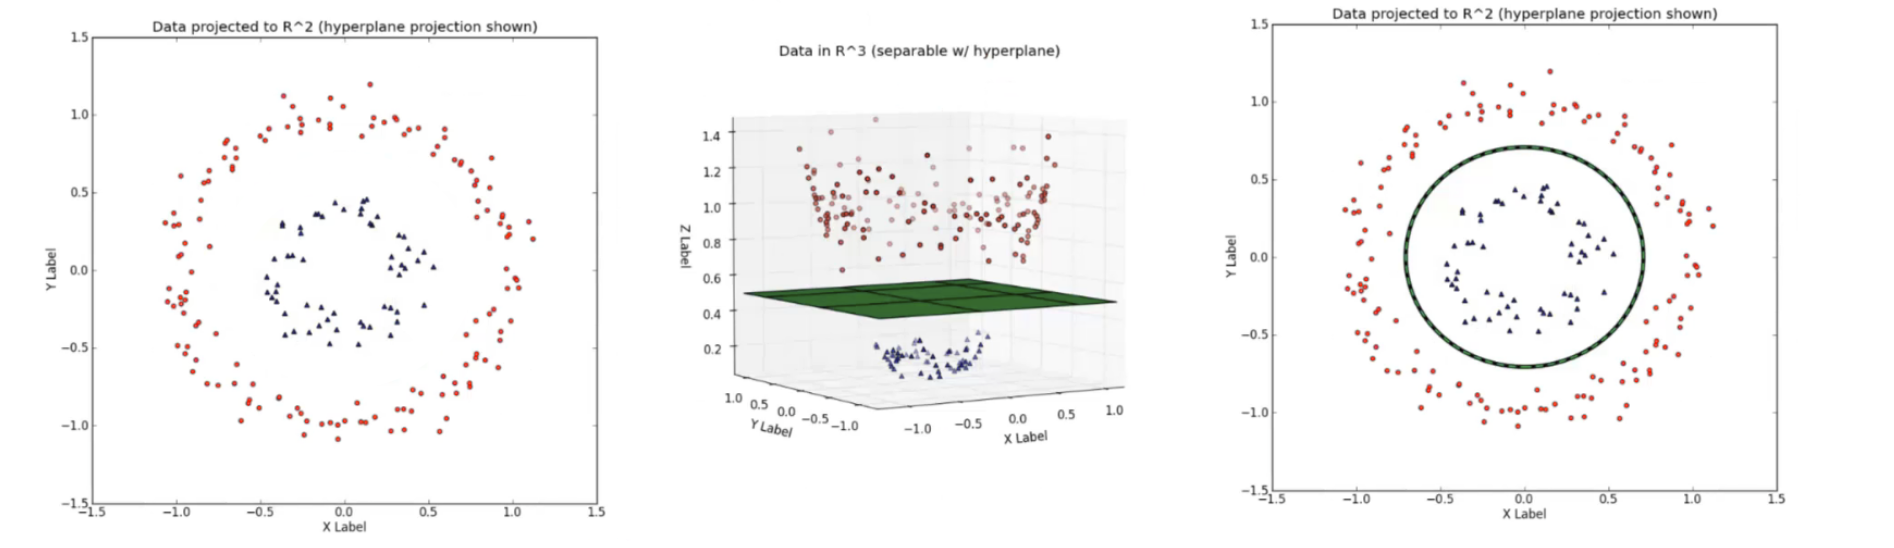

In 3-dimensional space, the boundary would be a (2-dimensional) plane. Therefore the boundary is generally called **hyperplane**, especially in higher dimensionalities we cannot imagine. The hyperplane is always of one dimension less than the design space.

**Q: How to transform the data?**

**A:** If we wanted to code this from scratch, we could test a feasible number of parameter combinations (&rarr; [GridSearch](https://spiced.space/poisson-ivy/ds-course/chapters/project_bicycles/hyperparameter_optimization/README.html)) to find the best results using Cross Validation (&rarr; this forenoon). But clever people have done this already.

## And another problem: The tremendous amount of possible parameters

Apart from polynomes, one could think of an arbitrary high number of possible additional features. For all of those, the transformation *and* the optimization of the loss would be required to find a separating hyperplane. This can easily become infeasible.

### The solution: The Kernel Trick

Thankfully we do not need to transform our data into the higher dimension but can make use of a mathematical trick. Without going into detail (see References for those), the relationsships between all pairs of observations in the higher dimension can be calculated using a so-called kernel function. The trick avoids the transformation by using a simple scalar product (= dot product):

$$K(\textbf{a},\textbf{b}) = \phi(\textbf{a})^T \cdot \phi(\textbf{b}) $$

Where $\phi$ is our transformation, $\textbf{a},\textbf{b}$ are (each) two points in our data and $\cdot$ is the dot product.

### Hyperparameters

[Hyperparameters](https://spiced.space/poisson-ivy/ds-course/chapters/project_bicycles/hyperparameter_optimization/README.html) are parameters that **we** have to set before the training (of the *model* parameters).

These are the hyperparameters which have to chose:

#### kernel

- linear kernel: basic kernel type; computational cheap but useful for linearly separable classes
- polynomial kernel: generalized version of the linear kernel, often less efficient and accurarte as other kernels
- RBF kernel: general purpose kernel, reasonable first choice for unknown boundaries 
- gaussian kernel: commonly used especially if dataset is unknown
- ...  


The right kernel choice is often outsourced by performing a grid search on this hyperparameter.

#### Regularisation term `C`

C penalizes misclassification  
A high value of C  
- means a small amount of regularization
- tends to overfit the model
- leads to a hard (but small) margin &emsp; &emsp; &emsp; &emsp; and vice versa  

Look [here](https://medium.com/swlh/the-conundrum-of-c-svm-hyperparameters-3327dfc7354a) for a more detailed explanation.

#### kernel coefficient `gamma`

For nonlinear kernels there is a hyperparameter Ɣ

It can be regarded as the inverse of the support vector influence radius.

A high value of gamma
- means small influence of the support vectors
- tend to overfit the model
- means that the data points need to be very close to each other to be considered in the same class

Have a look [here](https://towardsdatascience.com/hyperparameter-tuning-for-support-vector-machines-c-and-gamma-parameters-6a5097416167) for a more detailed explanation.

## Support vector machines in sklearn

*Caveate:* SVM are not scale invariant. If the features have different magnitudes, it is recommended to use a standard scale the $x_i$ first (`StandardScaler` from `sklearn`).

`sklearn` has two support vector classifiers:  
- `LinearSVC` - the fastest, use it if possible. Disadvantage: linear kernel
- `SVC` - general Support Vector machine Classifier with selectable kernel. Disadvantage: much slower even with linear kernel

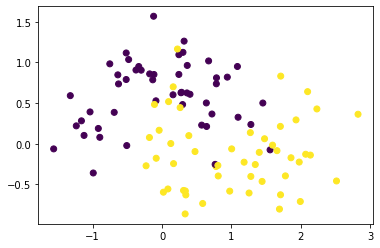

In [4]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X, y = make_moons(noise=.3, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y)

train_score=0.8933333333333333,test_score=0.92


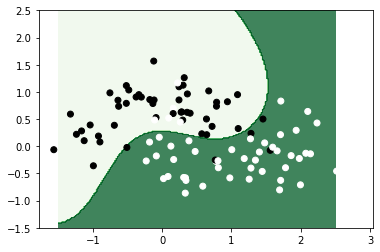

In [14]:
#####################
m = SVC()           # This line is really the only new piece of code you need to understand. Try different C's.
#####################

X_train, X_test, y_train, y_test = train_test_split(X, y)


m.fit(X_train, y_train)
print(f'train_score={m.score(X_train, y_train)},test_score={m.score(X_test, y_test)}')


# ALL ABOUT PLOTTING
N = 200
coord = np.linspace(-1.5, 2.5, N)
xx, yy = np.meshgrid(coord, coord)

Xpred = np.array(list(zip(xx.reshape(N ** 2), yy.reshape(N ** 2))))
ypred = m.predict(Xpred)

colors = np.array(['black', 'white'])

Z = ypred.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.75, cmap=plt.cm.Greens)

plt.scatter(X[:, 0], X[:, 1], color=colors[y])

plt.show()

## Summary

**Advantages**:
- Requires less feature engineering than other ML algorithms by increasing the dimensionality
- can handel non-linear decision boundaries
- can handle lots of features

**Disadvantages**:
- Requires a hyperparameter search (They don't tune themselves. &rarr; GridSearch)
- data should be scaled
- does not produce probabilities by itself (look [here](https://spiced.space/poisson-ivy/ds-course/chapters/project_titanic/support_vector_machines/README.html#advantages-of-svms) how to overcome this)
- gets very slow for large data sets.

## Links

- [Explanation of algorithm, kernel, which to chose, etc.](https://www.analyticsvidhya.com/blog/2021/10/support-vector-machinessvm-a-complete-guide-for-beginners/)
- [Video explaining the basics (+ links to further explanations)](https://www.youtube.com/watch?v=efR1C6CvhmE)
- [math. explanations including the loss function of SVM](https://www.cs.toronto.edu/~mbrubake/teaching/C11/Handouts/SupportVectorMachines.pdf)
- [simple example on kernel trick](https://www.quora.com/What-are-kernels-in-machine-learning-and-SVM-and-why-do-we-need-them/answer/Lili-Jiang?srid=oOgT)
- [How to decide which kernel to use?](https://www.quora.com/Machine-Learning/How-does-one-decide-on-which-kernel-to-choose-for-an-SVM-RBF-vs-linear-vs-poly-kernel)
- [What is a slack variable?](https://www.quora.com/unanswered/What-is-a-slack-variable-in-SVM)
- [Example showing how to tune hyperparameters](https://www.youtube.com/watch?v=203zKEecHgg)